## Employee Attrition Prediction

\importing necessary libraries

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

from sklearn.model_selection import train_test_split

\loading the merged dataset

In [82]:
df = pd.read_csv(r"C:\NG\Employee Attrition Prediction\data\merged_data\employee_merged.csv")
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,avg_work_hours
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.0,Y,11,8,0,1.0,6,1,0,0,3.0,4.0,2.0,3,3,7.37
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.0,Y,23,8,1,6.0,3,5,1,4,3.0,2.0,4.0,2,4,7.72
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.0,Y,15,8,3,5.0,2,5,0,3,2.0,2.0,1.0,3,3,7.01
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.0,Y,11,8,3,13.0,5,8,7,5,4.0,4.0,3.0,2,3,7.19
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.0,Y,12,8,2,9.0,2,6,0,4,4.0,1.0,3.0,3,3,8.01


In [83]:
df.shape

(4410, 30)

\train test split

In [84]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Split done ")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("\nTrain target %:")
print((y_train.value_counts(normalize=True)*100).round(2).to_dict())
print("Test target %:")
print((y_test.value_counts(normalize=True)*100).round(2).to_dict())

Split done 
X_train: (3528, 29) | X_test: (882, 29)

Train target %:
{0: 83.87, 1: 16.13}
Test target %:
{0: 83.9, 1: 16.1}


### data preprocessing

\dropping constant value columns and useless cols

In [85]:
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID']

X_train = X_train.drop(columns=drop_cols)
X_test  = X_test.drop(columns=drop_cols)

print("Dropped useless columns ")
print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("\nRemaining columns:", list(X_train.columns))

Dropped useless columns 
X_train shape: (3528, 25)
X_test  shape: (882, 25)

Remaining columns: ['Age', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_work_hours']


\missing value imputation

In [86]:
mode_cols   = ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance'] 
median_cols = ['NumCompaniesWorked', 'TotalWorkingYears']                       

fill_values = {}
for col in mode_cols:
    fill_values[col] = X_train[col].mode()[0]     
for col in median_cols:
    fill_values[col] = X_train[col].median()      

print("Fill values learned from TRAIN:")
print(fill_values)

X_train = X_train.fillna(fill_values)
X_test  = X_test.fillna(fill_values)

print("\nMissing in X_train:", X_train.isnull().sum().sum())
print("Missing in X_test :", X_test.isnull().sum().sum())

Fill values learned from TRAIN:
{'EnvironmentSatisfaction': np.float64(3.0), 'JobSatisfaction': np.float64(4.0), 'WorkLifeBalance': np.float64(3.0), 'NumCompaniesWorked': np.float64(2.0), 'TotalWorkingYears': np.float64(10.0)}

Missing in X_train: 0
Missing in X_test : 0


In [87]:
print("Data types after cleaning:")
print(X_train.dtypes.value_counts())
print("\nCategorical (object) columns:")
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print(cat_cols)

Data types after cleaning:
int64      13
str         6
float64     6
Name: count, dtype: int64

Categorical (object) columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


\outlier detection

In [88]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = {}
for col in numeric_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    pct = round(n_out / len(X_train) * 100, 2)
    outlier_summary[col] = {'lower': round(lower,2), 'upper': round(upper,2),
                            'n_outliers': n_out, 'pct': pct}


In [89]:
outlier_df = pd.DataFrame(outlier_summary).T.sort_values('n_outliers', ascending=False)
print("Outlier summary (IQR method, TRAIN):\n")
outlier_df

Outlier summary (IQR method, TRAIN):



,lower,upper,n_outliers,pct
TrainingTimesLastYear,0.50,4.50,556.0,15.76
PerformanceRating,3.00,3.00,555.0,15.73
YearsSinceLastPromotion,-3.00,5.00,511.0,14.48
MonthlyIncome,-53152.50,165547.50,276.0,7.82
YearsAtCompany,-6.00,18.00,241.0,6.83
StockOptionLevel,-1.50,2.50,201.0,5.70
TotalWorkingYears,-7.50,28.50,153.0,4.34
NumCompaniesWorked,-3.50,8.50,130.0,3.68
YearsWithCurrManager,-5.50,14.50,33.0,0.94
avg_work_hours,4.11,10.96,23.0,0.65


### Outlier Treatment Decision

Findings:
- Outliers mainly in: YearsSinceLastPromotion, YearsAtCompany, 
  TotalWorkingYears (all < 3%)
- These are GENUINE values — senior/long-tenured employees really exist
- Such employees are important attrition signals

Decision: KEEP outliers (no removal/capping).

Reasons:
1. They are real, valid HR values 
2. Removing = losing real attrition patterns
3. Our main models (RF, Gradient Boosting, XGBoost) are 
   tree-based → naturally robust to outliers
4. Only Logistic Regression is sensitive → scaling
   will reduce their impact


### EDA

In [90]:
#combining feature + target of train data
train_eda = X_train.copy()
train_eda["Attrition"] = y_train.values

print("Shape:", train_eda.shape)
print("Overall attrition rate:", round(train_eda['Attrition'].mean()*100, 2), "%")

Shape: (3528, 26)
Overall attrition rate: 16.13 %


\target distribution

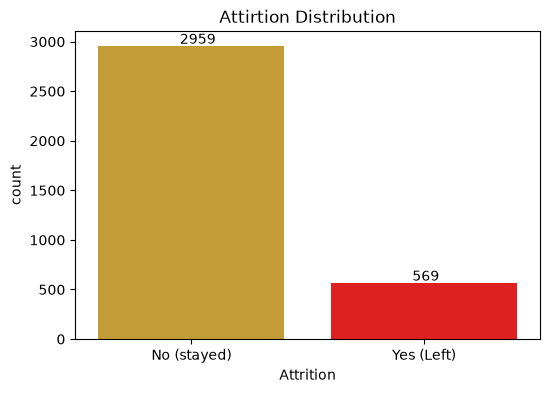

In [91]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "Attrition", data = train_eda , palette = ["goldenrod","red"])
ax.set_xticklabels(["No (stayed)","Yes (Left)"])
plt.title("Attirtion Distribution")
for p in ax.patches:
    ax.annotate(int(p.get_height()),(p.get_x()+0.35,p.get_height()+20))
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\target_distribution.png",dpi=100,bbox_inches="tight")


### Insights

-- Most employees stayed with the company (2,959), while only 569 employees left, showing that employee attrition is relatively low in this dataset.

-- The target variable is imbalanced, so methods like class weighting or resampling should be considered during model training to avoid biased predictions.

\Univariate Analysis

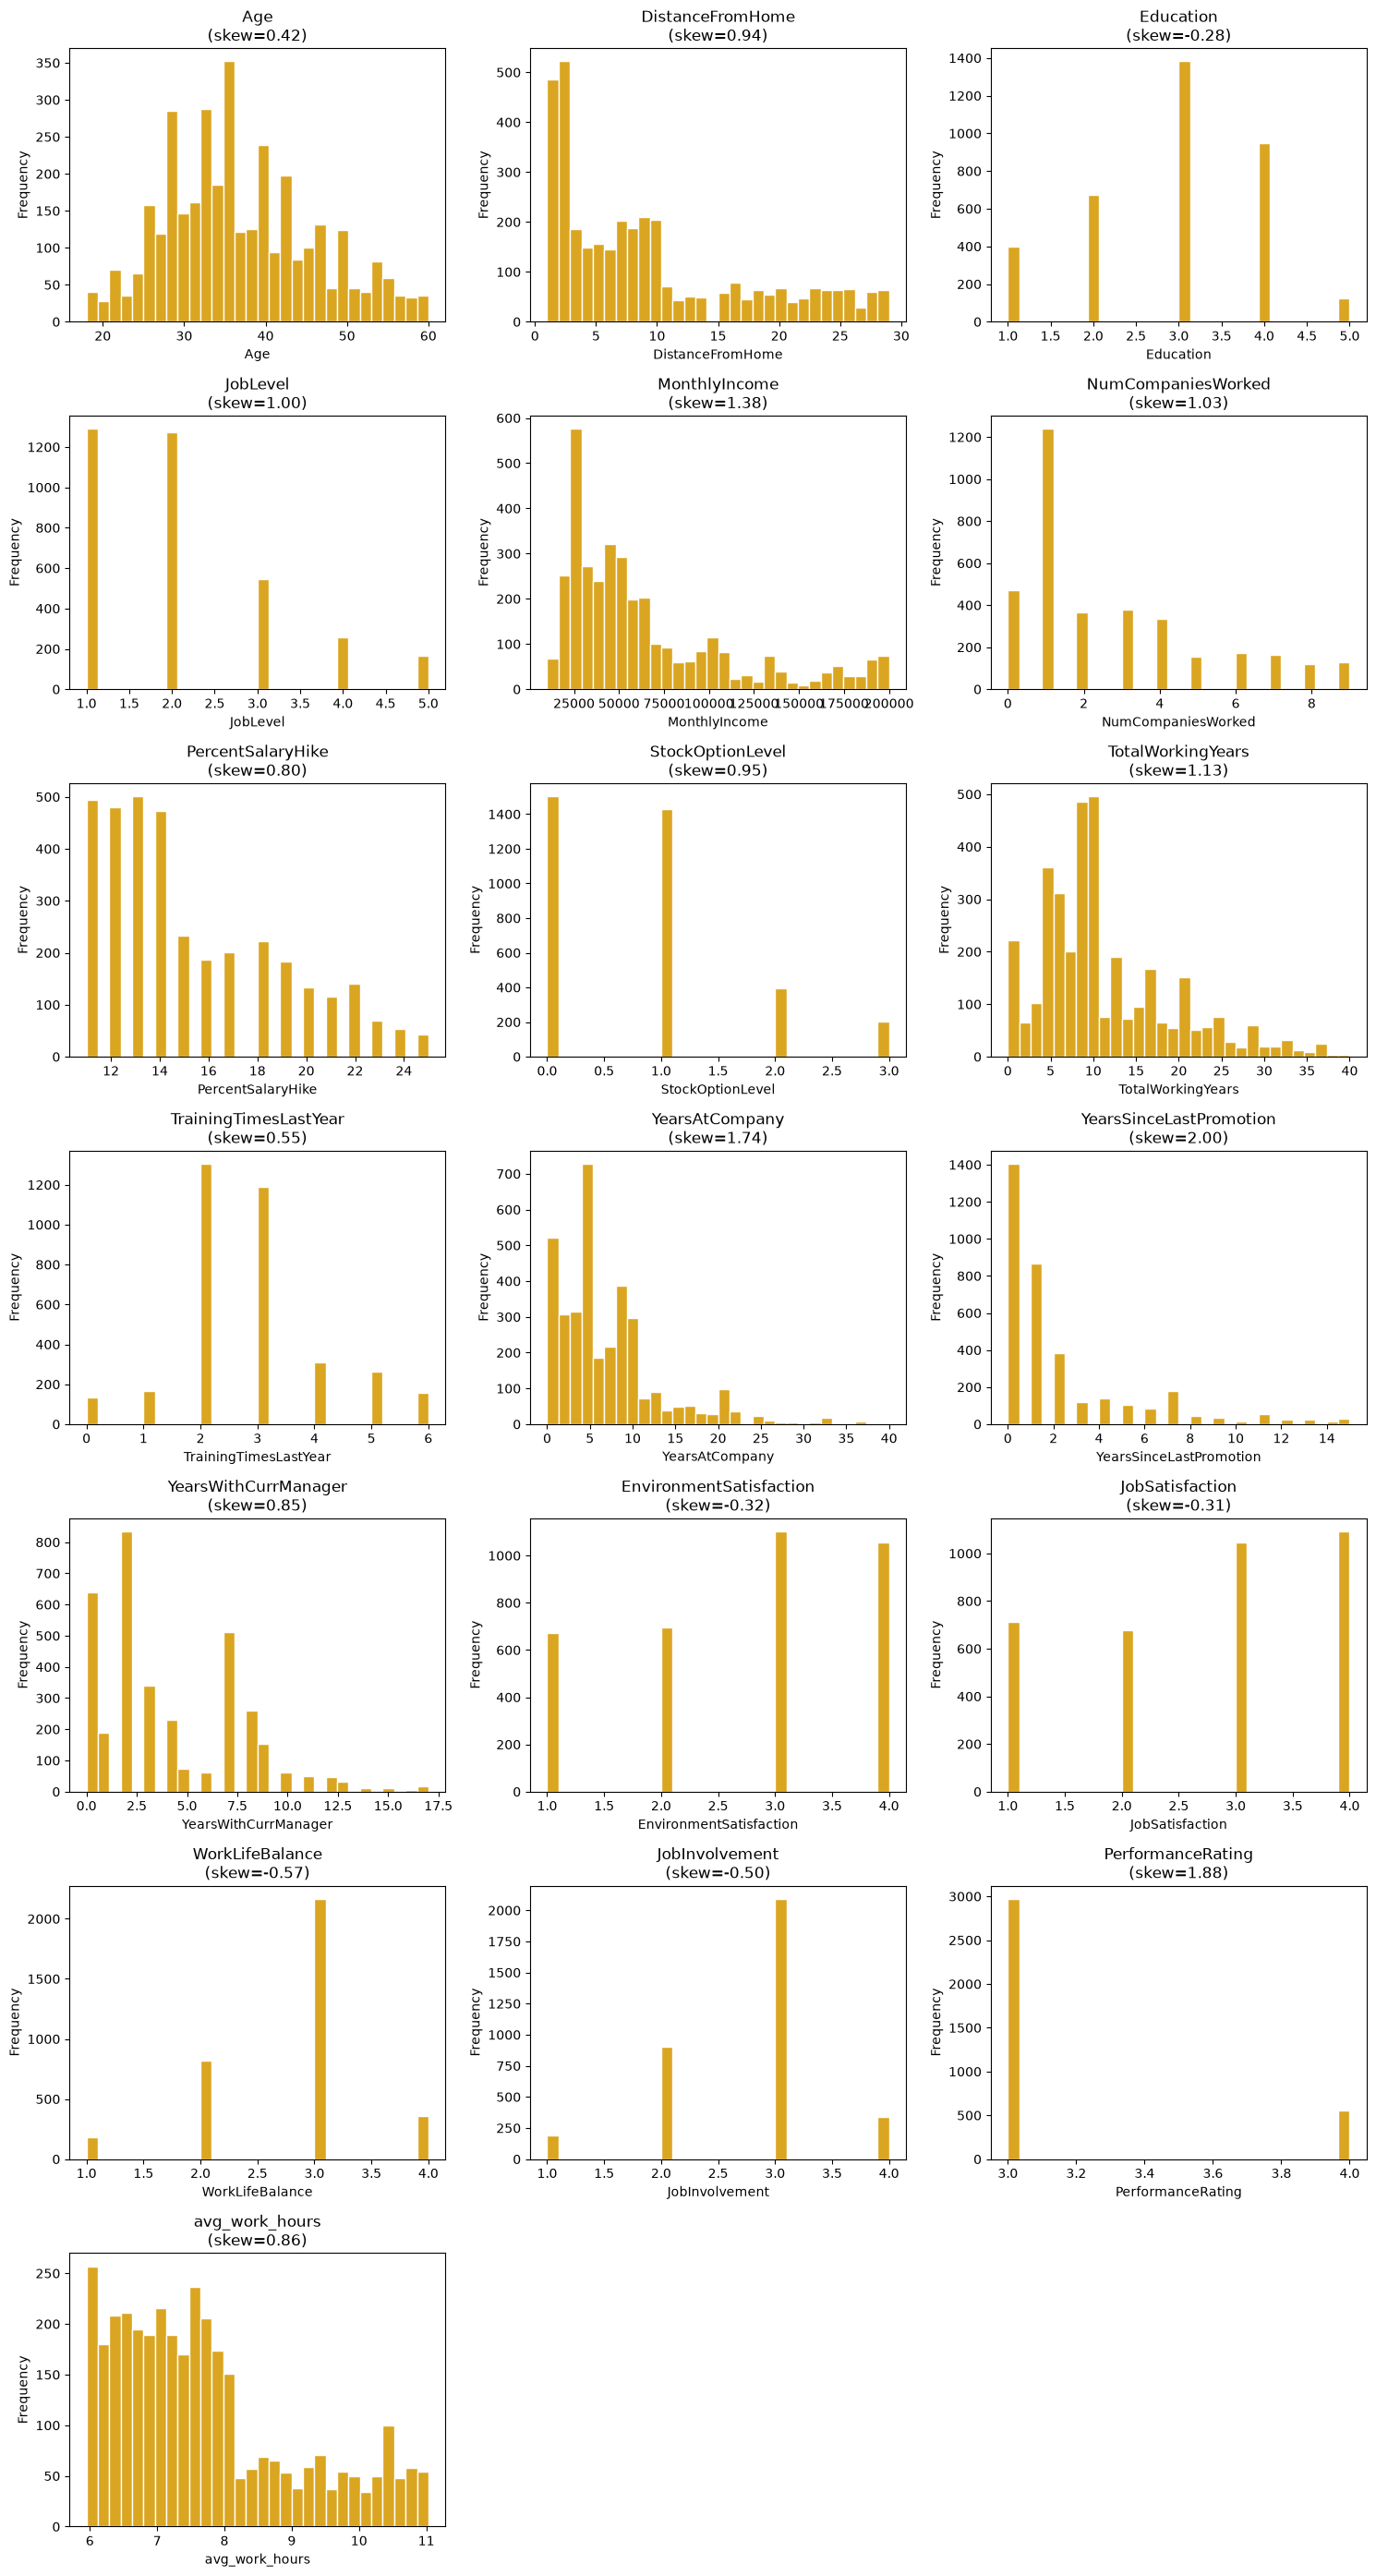

In [92]:
#numeric column analysis
numeric_cols = train_eda.select_dtypes(include=np.number).columns.tolist()
if "Attrition" in numeric_cols:
    numeric_cols.remove("Attrition")

if len(numeric_cols) == 0:
    print("No numeric features to plot.")

n = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols 

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()  

for i, col in enumerate(numeric_cols):
    axes[i].hist(train_eda[col], bins=30, color='goldenrod', edgecolor='white')
    skew = train_eda[col].skew()
    axes[i].set_title(f"{col}\n(skew={skew:.2f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\numeric_distribution.png",dpi=100,bbox_inches="tight")
plt.show()

### Insights

-- Most numerical features are slightly to highly right-skewed, showing that many employees fall into the lower value range while only a few have very high values.

-- Employees are mainly in the age group of 25–40 years, and most have less than 10 years of total work experience.

-- Features like MonthlyIncome, YearsAtCompany, and YearsSinceLastPromotion have a few employees with much higher values than the rest.

-- Variables such as Education, JobLevel, JobSatisfaction, EnvironmentSatisfaction, and WorkLifeBalance are discrete, with only a few fixed categories.

-- Most employees have a Performance Rating of 3, while only a small number have a rating of 4, indicating an uneven distribution.

-- The average working hours are mostly between 6 and 8 hours, with only a few employees working significantly longer.

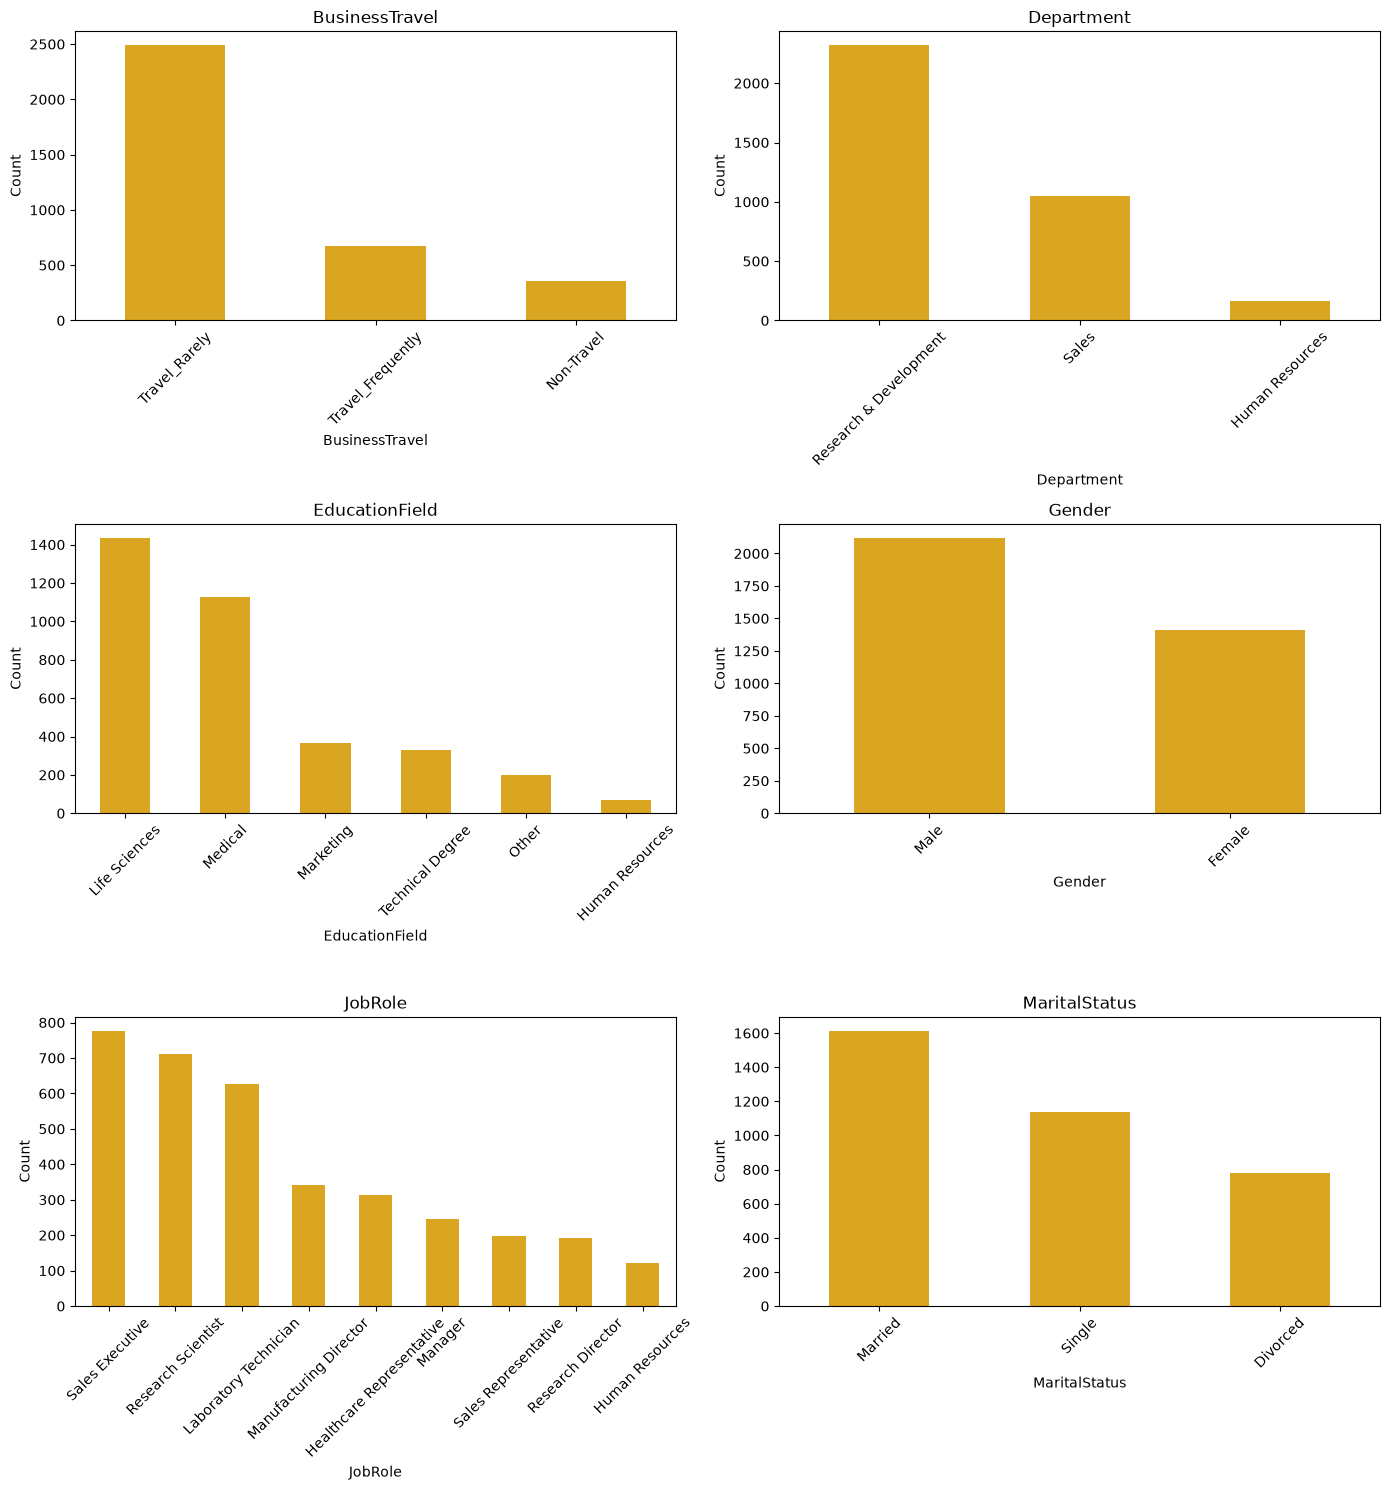

In [93]:
#categorical coln analysis
cat_cols = train_eda.select_dtypes(include="object").columns.tolist()
if "Attrition" in cat_cols:
    cat_cols.remove("Attrition")

if len(cat_cols) == 0:
    print("No suitable categorical features to plot.")
    
n = len(cat_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    train_eda[col].value_counts().plot(kind="bar", ax=axes[i], color="goldenrod")
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\categorical_distribution.png",dpi=100,bbox_inches="tight")
plt.show()


### Insights

-- Most employees travel rarely for work, while only a smaller group travels frequently or does not travel at all.

-- The majority of employees work in the Research & Development department, followed by Sales, with Human Resources having the fewest employees.

-- Most employees have an education background in Life Sciences or Medical, while the other education fields have fewer employees.

-- The workforce has more male employees than female employees, indicating a moderate gender imbalance in the dataset.

-- The most common job roles are Sales Executive, Research Scientist, and Laboratory Technician, while Human Resources has the smallest representation.

-- Most employees are married, followed by single employees, while divorced employees make up the smallest group.

\Bivariate Analysis

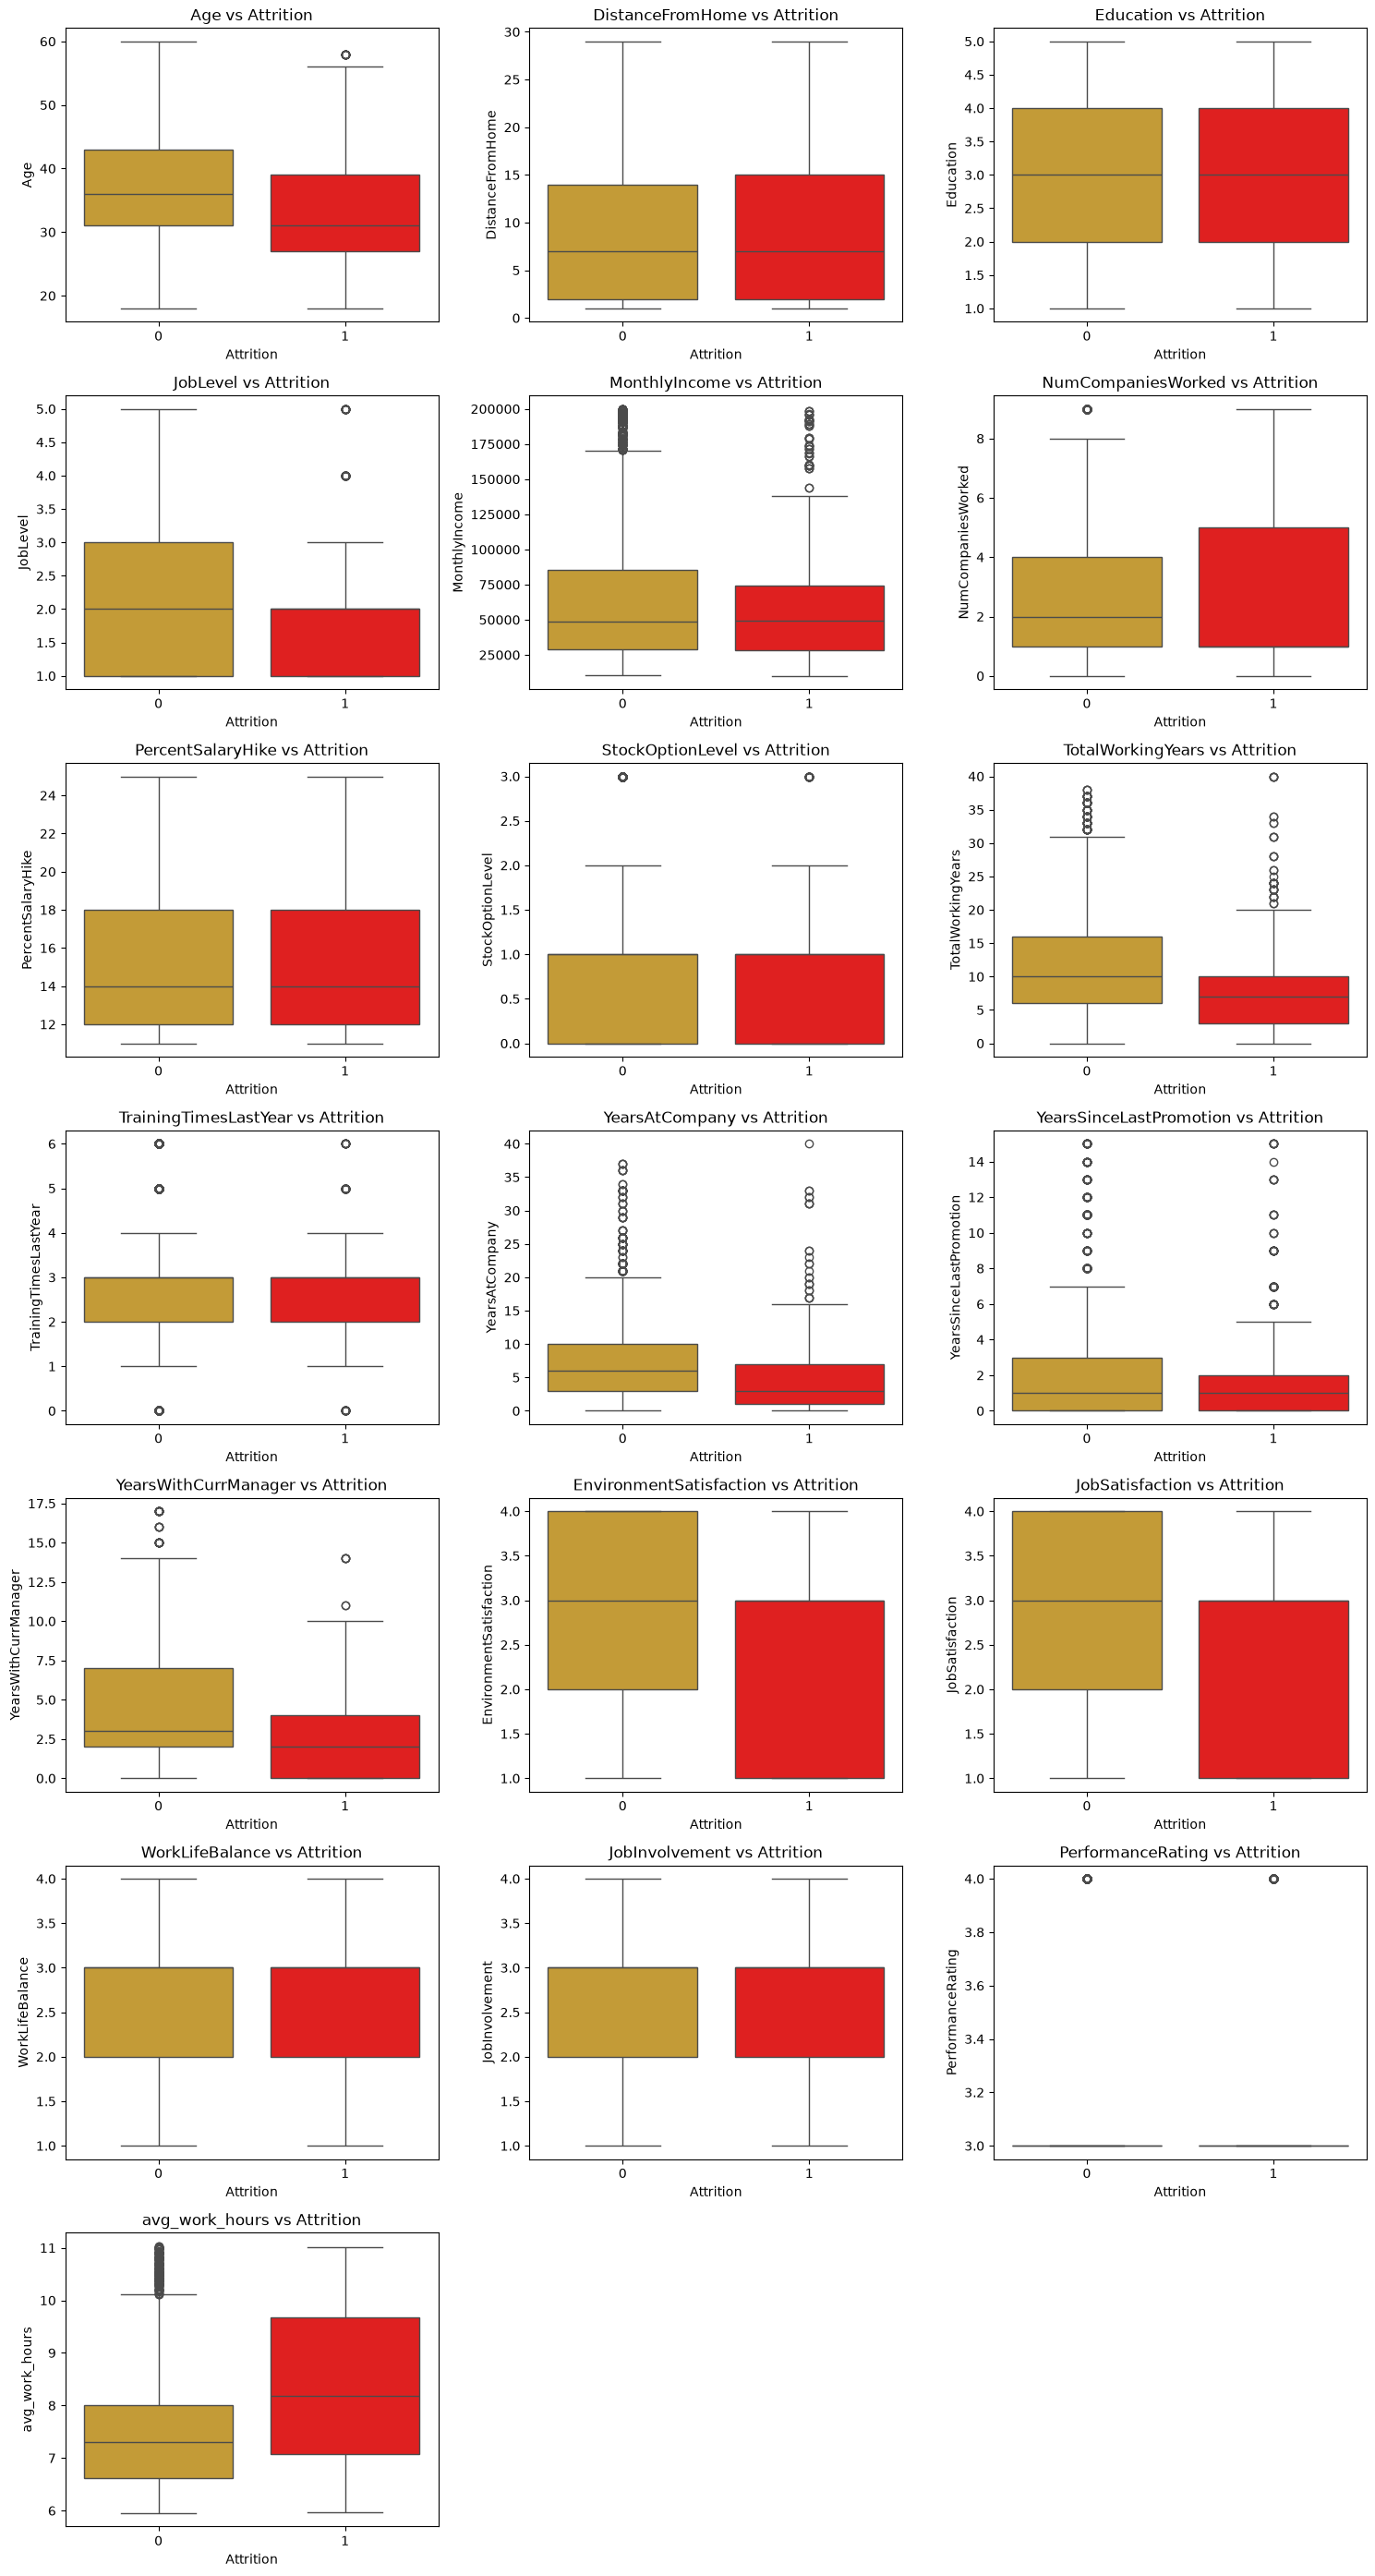

In [94]:
#numeric vs attrition analysis
numeric_cols = train_eda.select_dtypes(include=np.number).columns.tolist()
if "Attrition" in numeric_cols:
    numeric_cols.remove("Attrition")

if len(numeric_cols) == 0:
    print("No numeric features to plot.")

n = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()  

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(
        x="Attrition",
        y=col,
        data=train_eda,
        palette=["goldenrod", "red"],
        ax=ax
    )
    ax.set_title(f"{col} vs Attrition")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\numeric_vs_attrition.png",dpi=100,bbox_inches="tight")
plt.show()

### Insights

-- Employees who left the company are generally younger and have fewer total working years compared to those who stayed.

-- Employees with lower job levels and fewer years at the company show a higher chance of leaving.

-- People who travel longer distances to work and work more hours on average seem to leave more often.

-- Employees who left have slightly lower environment satisfaction and job satisfaction, which may have influenced their decision.

-- Monthly income, education level, salary hike, work-life balance, and performance rating do not show a strong difference between employees who stayed and those who left.

-- Overall, experience, job level, working hours, and satisfaction appear to have a bigger impact on employee attrition than salary or education.

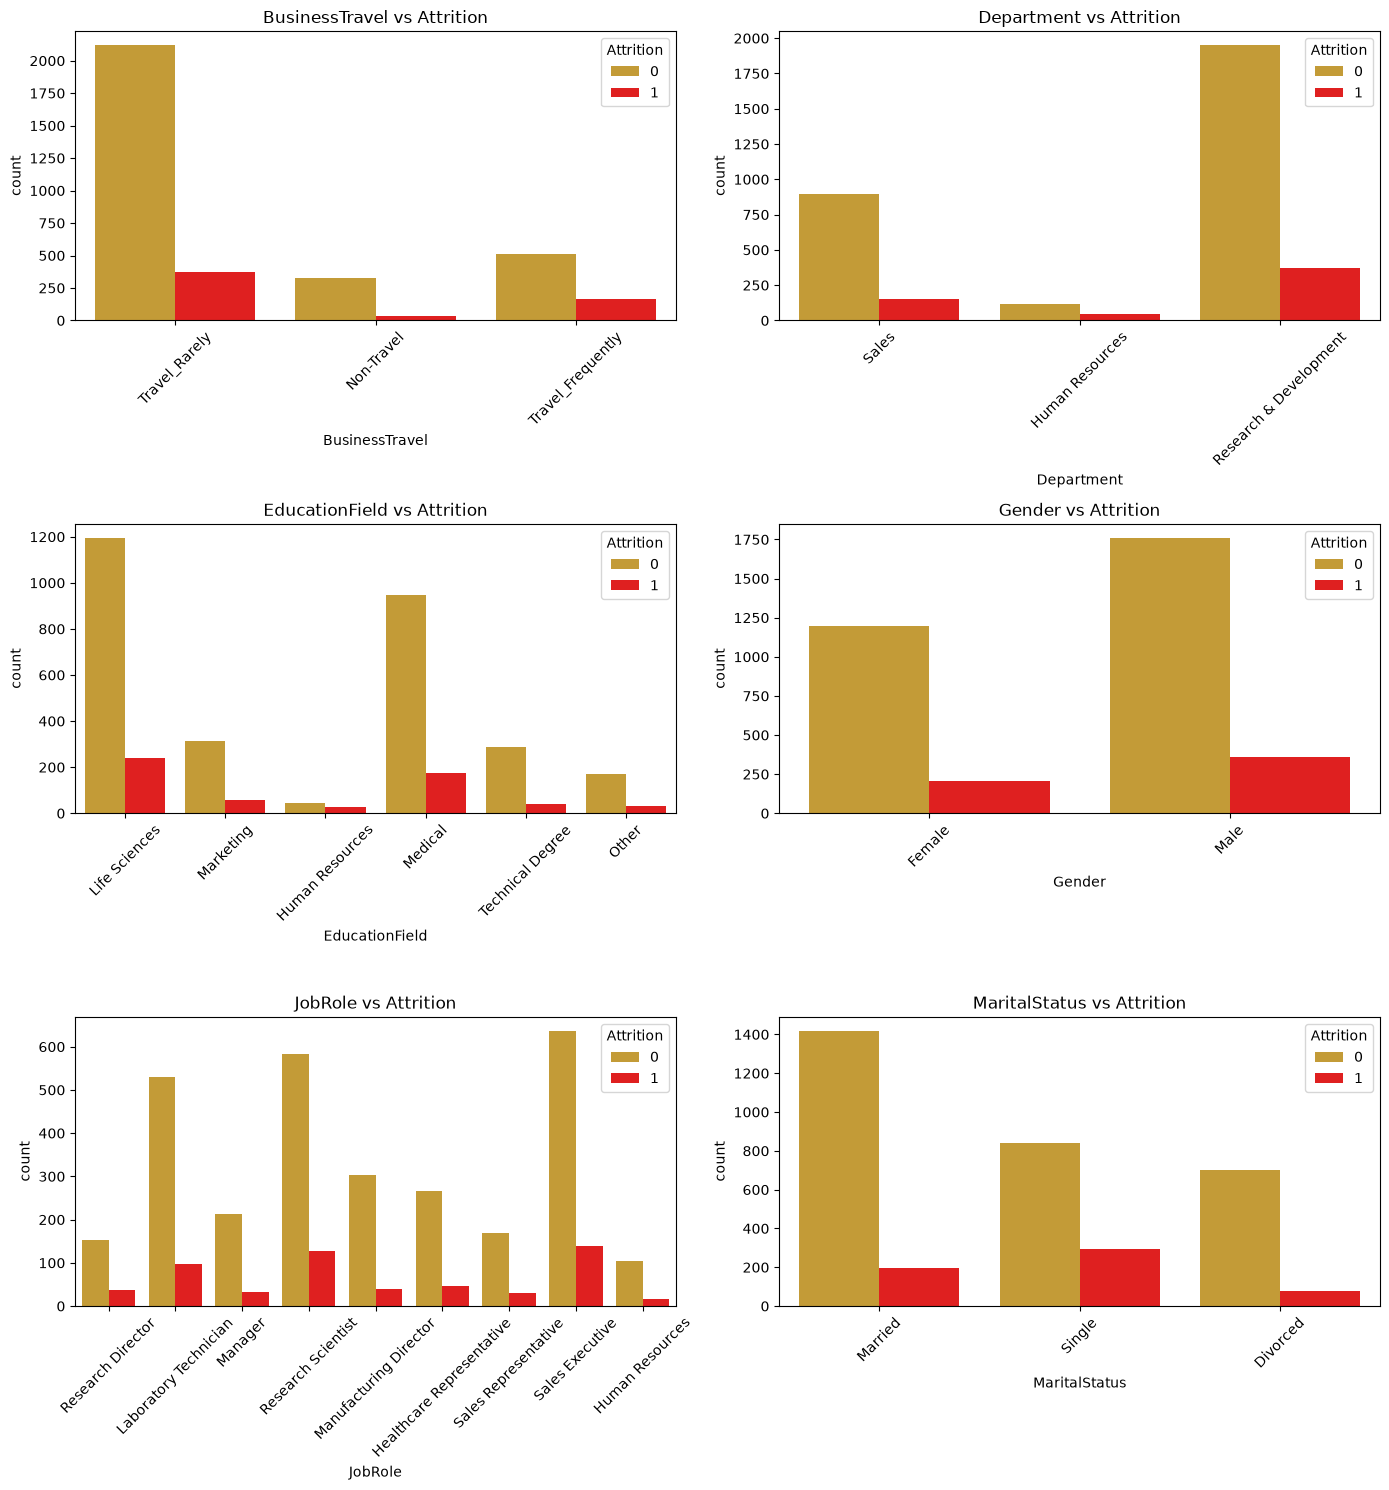

In [95]:
#categorical vs attrition analysis
cat_cols = train_eda.select_dtypes(include="object").columns.tolist()
if "Attrition" in cat_cols:
    cat_cols.remove("Attrition")

if len(cat_cols) == 0:
    print("No suitable categorical features to plot.")
    
n = len(cat_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(
        data=train_eda,
        x=col,
        hue="Attrition",
        palette=["goldenrod", "red"],
        ax=ax
    )
    ax.set_title(f"{col} vs Attrition")
    ax.tick_params(axis='x', rotation=45)

for j in range(n, len(axes)):
    axes[j].set_visible(False)
        
plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\categorical_vs_attrition.png", dpi=100, bbox_inches='tight')
plt.show()

### Insights

-- Employees who travel frequently for work have a higher attrition rate than those who travel rarely or do not travel.

-- The Research & Development department has the highest number of employees leaving, mainly because it has the largest workforce. Sales also shows a noticeable number of exits.

-- Employees from the Life Sciences and Medical education fields account for most attrition, while other education fields have fewer employees leaving.

-- Male employees have a slightly higher number of resignations than female employees, but this also reflects the higher number of male employees in the company.

-- Sales Executives, Research Scientists, and Laboratory Technicians show the highest employee turnover among all job roles.

-- Single employees leave the company more often than married or divorced employees, suggesting marital status may have some influence on attrition.

\correlation Analysis

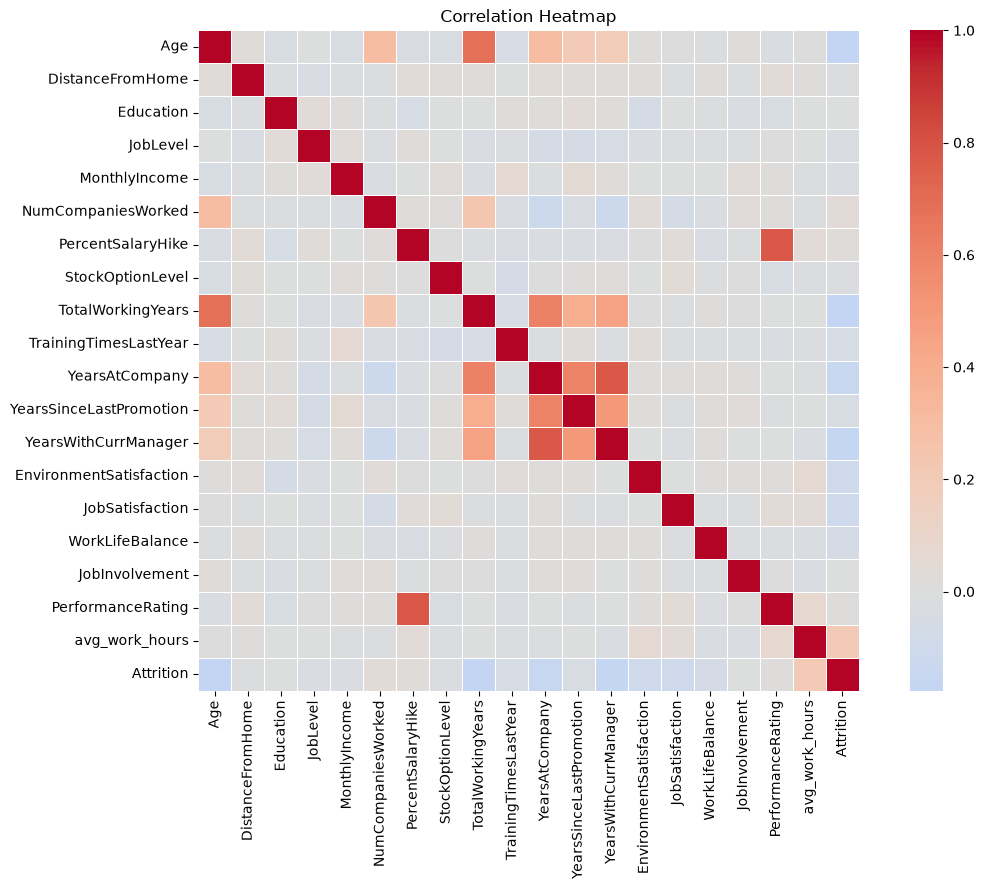

Top features correlated with 'Attrition':
  avg_work_hours: 0.206
  TotalWorkingYears: 0.177
  Age: 0.168
  YearsWithCurrManager: 0.163
  YearsAtCompany: 0.151
  JobSatisfaction: 0.107
  EnvironmentSatisfaction: 0.099
  WorkLifeBalance: 0.062
  TrainingTimesLastYear: 0.047
  YearsSinceLastPromotion: 0.042


In [96]:
numeric_df = train_eda.select_dtypes(include=np.number)

if numeric_df.shape[1]<2:
    print("Need atleast 2 numeric columns for correlation")
    
corr = numeric_df.corr()

fig,ax = plt.subplots(figsize=(12,9))
sns.heatmap(corr,annot=False,cmap="coolwarm",center=0,square=True,linewidths=0.5,ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(r"C:\NG\Employee Attrition Prediction\reports\correlation_analysis.png", dpi=100, bbox_inches='tight')
plt.show()

if "Attrition" is not None and "Attrition" in numeric_df.columns:
    Attrition_corr = corr["Attrition"].drop("Attrition").abs().sort_values(ascending=False)
    print(f"Top features correlated with '{"Attrition"}':")
    for col ,val in Attrition_corr.head(10).items():
        print(f"  {col}: {val:.3f}")

### Insights

-- Most features have a weak correlation with attrition, showing that employee turnover is influenced by multiple factors rather than a single variable.

-- Total Working Years, Years at Company, Years with Current Manager, and Years Since Last Promotion are positively correlated, as they all relate to employee experience.

-- Age is positively related to Total Working Years, indicating that older employees generally have more work experience.

-- Average work hours show a slight positive correlation with attrition, while experience-related features have a slight negative correlation with attrition.

### Feature Engineering

In [97]:
def add_engineered_features(data):
    
    d = data.copy()
    
    d['TenureRatio']      = d['YearsAtCompany'] / (d['TotalWorkingYears'] + 1)
    d['PromotionGap']     = d['YearsSinceLastPromotion'] / (d['YearsAtCompany'] + 1)
    d['IncomePerYear']    = d['MonthlyIncome'] / (d['TotalWorkingYears'] + 1)
    d['IsOverworked']     = (d['avg_work_hours'] > 8).astype(int)
    d['ManagerStability'] = d['YearsWithCurrManager'] / (d['YearsAtCompany'] + 1)
    
    return d

# Apply to both sets
X_train = add_engineered_features(X_train)
X_test  = add_engineered_features(X_test)

print("Feature engineering done ")
print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("\nNew features preview:")
X_train[['TenureRatio','PromotionGap','IncomePerYear','IsOverworked','ManagerStability']].sample(10)

Feature engineering done 
X_train shape: (3528, 30)
X_test  shape: (882, 30)

New features preview:


,TenureRatio,PromotionGap,IncomePerYear,IsOverworked,ManagerStability
3118,0.444444,0.200000,7391.111111,0,0.600000
2413,0.833333,0.166667,8281.666667,1,0.333333
2629,0.500000,0.333333,15312.500000,0,0.666667
3673,0.600000,0.250000,38378.000000,1,0.500000
4291,0.846154,0.333333,8026.923077,1,0.583333
2617,0.785714,0.333333,1644.285714,0,0.666667
835,0.800000,0.619048,1264.800000,1,0.428571
3766,0.909091,0.727273,2561.818182,1,0.545455
2611,0.909091,0.000000,8267.272727,0,0.818182
1857,0.500000,0.000000,9860.000000,1,0.500000


In [98]:
check = X_train[['TenureRatio','PromotionGap','IncomePerYear',
                 'IsOverworked','ManagerStability']].copy()
check['Attrition'] = y_train.values

print("New features — correlation with Attrition:")
print(check.corr()["Attrition"].drop('Attrition').sort_values())

New features — correlation with Attrition:
ManagerStability   -0.157657
TenureRatio        -0.108552
PromotionGap        0.006867
IncomePerYear       0.137340
IsOverworked        0.225307
Name: Attrition, dtype: float64


\Checking multicollinearity

In [99]:
corr_matrix =X_train.select_dtypes(include=np.number).corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))

high_corr = [(c,r,round(upper.loc[r,c],3))
             for c in upper.columns for r in upper.index
             if upper.loc[r,c]>0.85]

print("Highly correlated pairs (>0.85):")
if high_corr:
    for a, b, v in high_corr:
        print(f"  {b}  <->  {a}  =  {v}")
else:
    print("  None found ")

Highly correlated pairs (>0.85):
  None found 


-- There is no multicollinearity columns present in dataset